<a href="https://colab.research.google.com/github/KeerthanaSistla/Data-Profiling-and-Quality-Assessment/blob/main/Data_Profiling_and_Quality_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Setup & Data Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')

In [5]:
DATA_PATH = "agency_performance.csv"
SEP = ","
df_raw = pd.read_csv(DATA_PATH, sep=SEP)
print("Shape (rows, columns):", df_raw.shape)

Shape (rows, columns): (213328, 49)


In [6]:
df_raw = pd.read_csv(DATA_PATH, sep=SEP)
print("Shape (rows, columns):", df_raw.shape)

SENTINEL_VALUES = [99999, -99999, "99999"]  # extend if other placeholders are found

sentinel_report = []
for col in df_raw.columns:
    cnt = df_raw[col].isin(SENTINEL_VALUES).sum()
    if cnt > 0:
        sentinel_report.append({
            "column": col,
            "sentinel_count": cnt,
            "pct_of_rows": round(cnt / len(df_raw) * 100, 2)
        })

sentinel_df = pd.DataFrame(sentinel_report).sort_values("pct_of_rows", ascending=False)
print(f"Columns containing the 99999 sentinel value: {len(sentinel_df)} of {df_raw.shape[1]}")

df = df_raw.replace(SENTINEL_VALUES, np.nan)
print("Sentinel values replaced with NaN. Re-checking dtypes (some int columns may become float due to NaN):")
print(df.dtypes.value_counts())

Shape (rows, columns): (213328, 49)
Columns containing the 99999 sentinel value: 36 of 49
Sentinel values replaced with NaN. Re-checking dtypes (some int columns may become float due to NaN):
float64    39
int64       5
object      5
Name: count, dtype: int64


#2. Schema Discovery & Validation

In [7]:
print("Column names:")
for c in df.columns:
    print(" -", c)

print("Data types:\n")
print(df.dtypes)

df.head(10)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
datetime_like_cols = [c for c in df.columns if 'date' in c.lower() or 'dt' in c.lower()]

print("Numeric columns:", numeric_cols)
print("\nCategorical columns:", categorical_cols)
print("\nPossible date columns (by name heuristic, to verify manually):", datetime_like_cols)

Column names:
 - AGENCY_ID
 - PRIMARY_AGENCY_ID
 - PROD_ABBR
 - PROD_LINE
 - STATE_ABBR
 - STAT_PROFILE_DATE_YEAR
 - RETENTION_POLY_QTY
 - POLY_INFORCE_QTY
 - PREV_POLY_INFORCE_QTY
 - NB_WRTN_PREM_AMT
 - WRTN_PREM_AMT
 - PREV_WRTN_PREM_AMT
 - PRD_ERND_PREM_AMT
 - PRD_INCRD_LOSSES_AMT
 - MONTHS
 - RETENTION_RATIO
 - LOSS_RATIO
 - LOSS_RATIO_3YR
 - GROWTH_RATE_3YR
 - AGENCY_APPOINTMENT_YEAR
 - ACTIVE_PRODUCERS
 - MAX_AGE
 - MIN_AGE
 - VENDOR_IND
 - VENDOR
 - PL_START_YEAR
 - PL_END_YEAR
 - COMMISIONS_START_YEAR
 - COMMISIONS_END_YEAR
 - CL_START_YEAR
 - CL_END_YEAR
 - ACTIVITY_NOTES_START_YEAR
 - ACTIVITY_NOTES_END_YEAR
 - CL_BOUND_CT_MDS
 - CL_QUO_CT_MDS
 - CL_BOUND_CT_SBZ
 - CL_QUO_CT_SBZ
 - CL_BOUND_CT_eQT
 - CL_QUO_CT_eQT
 - PL_BOUND_CT_ELINKS
 - PL_QUO_CT_ELINKS
 - PL_BOUND_CT_PLRANK
 - PL_QUO_CT_PLRANK
 - PL_BOUND_CT_eQTte
 - PL_QUO_CT_eQTte
 - PL_BOUND_CT_APPLIED
 - PL_QUO_CT_APPLIED
 - PL_BOUND_CT_TRANSACTNOW
 - PL_QUO_CT_TRANSACTNOW
Data types:

AGENCY_ID                      in

#3. Data Dictionary

In [8]:
def build_data_dictionary(data: pd.DataFrame) -> pd.DataFrame:
    rows = []
    n = len(data)
    for col in data.columns:
        missing = data[col].isna().sum()
        pct_missing = round((missing / n) * 100, 2) if n else 0
        unique_vals = data[col].nunique(dropna=True)
        sample_val = data[col].dropna().iloc[0] if data[col].dropna().shape[0] > 0 else None
        rows.append({
            "column_name": col,
            "dtype": str(data[col].dtype),
            "missing_count": missing,
            "pct_missing": pct_missing,
            "unique_values": unique_vals,
            "sample_value": sample_val
        })
    return pd.DataFrame(rows).sort_values("pct_missing", ascending=False).reset_index(drop=True)

data_dictionary = build_data_dictionary(df)
data_dictionary

# Save data dictionary as its own artifact for the submission
data_dictionary.to_csv("data_dictionary.csv", index=False)
print("Saved data_dictionary.csv")

Saved data_dictionary.csv


#4. Duplicate Records & High-Missing Columns

In [9]:
full_dupes = df.duplicated().sum()
print(f"Fully duplicated rows: {full_dupes} ({round(full_dupes/len(df)*100,2)}% of dataset)")

id_like_cols = [c for c in df.columns if 'id' in c.lower() or 'number' in c.lower() or 'policy' in c.lower()]
print("\nPossible identifier columns (verify manually):", id_like_cols)

for c in id_like_cols:
    dup_id = df[c].duplicated().sum()
    print(f" - Duplicate values in '{c}': {dup_id}")

HIGH_MISSING_THRESHOLD = 30

high_missing_cols = data_dictionary[data_dictionary["pct_missing"] > HIGH_MISSING_THRESHOLD]
print(f"Columns with >{HIGH_MISSING_THRESHOLD}% missing values:")
high_missing_cols[["column_name", "pct_missing"]]

Fully duplicated rows: 0 (0.0% of dataset)

Possible identifier columns (verify manually): ['AGENCY_ID', 'PRIMARY_AGENCY_ID']
 - Duplicate values in 'AGENCY_ID': 211705
 - Duplicate values in 'PRIMARY_AGENCY_ID': 212740
Columns with >30% missing values:


,column_name,pct_missing
0,ACTIVITY_NOTES_END_YEAR,98.09
1,PL_END_YEAR,98.05
2,COMMISIONS_END_YEAR,96.38
3,CL_END_YEAR,95.98
4,ACTIVITY_NOTES_START_YEAR,80.41
5,COMMISIONS_START_YEAR,66.53
6,RETENTION_RATIO,60.93
7,CL_START_YEAR,60.62
8,CL_BOUND_CT_MDS,46.26
9,CL_BOUND_CT_eQT,46.26


#5. Cleaning Categorical Columns

In [10]:
df_clean = df.copy()

for col in categorical_cols:
    df_clean[col] = (
        df_clean[col]
        .astype(str)
        .str.strip()
        .str.title()
        .replace({'Nan': np.nan, 'None': np.nan, '': np.nan})
    )

print("Cleaned categorical columns:", categorical_cols)
df_clean[categorical_cols].head(10)

Cleaned categorical columns: ['PROD_ABBR', 'PROD_LINE', 'STATE_ABBR', 'VENDOR_IND', 'VENDOR']


,PROD_ABBR,PROD_LINE,STATE_ABBR,VENDOR_IND,VENDOR
0,Boilermach,Cl,In,N,Unknown
1,Boilermach,Cl,In,N,Unknown
2,Boilermach,Cl,In,N,Unknown
3,Boilermach,Cl,In,N,Unknown
4,Boilermach,Cl,In,N,Unknown
5,Boilermach,Cl,In,N,Unknown
6,Boilermach,Cl,In,N,Unknown
7,Boilermach,Cl,In,N,Unknown
8,Boilermach,Cl,In,N,Unknown
9,Boilermach,Cl,In,N,Unknown


In [11]:
full_dupes_after = df_clean.duplicated().sum()
print(f"Fully duplicated rows AFTER cleaning: {full_dupes_after}")

df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df_clean.shape)

Fully duplicated rows AFTER cleaning: 0
Shape after dropping duplicates: (213328, 49)


#6. Visualizations

Chart 1: Missing values per column (only columns with at least 1 missing value)

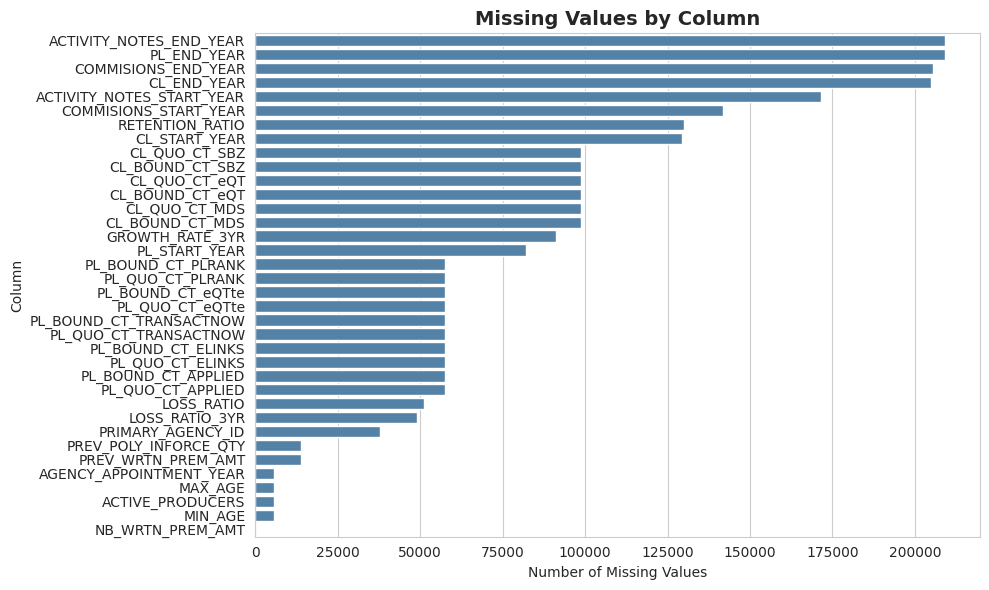

In [12]:
missing_counts = df.isna().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_counts.values, y=missing_counts.index, color="steelblue")
plt.title("Missing Values by Column", fontsize=14, fontweight='bold')
plt.xlabel("Number of Missing Values")
plt.ylabel("Column")
plt.tight_layout()
plt.savefig("chart1_missing_values.png", dpi=150)
plt.show()

Chart 2: Distribution of a key numeric metric (Written Premium Amount)

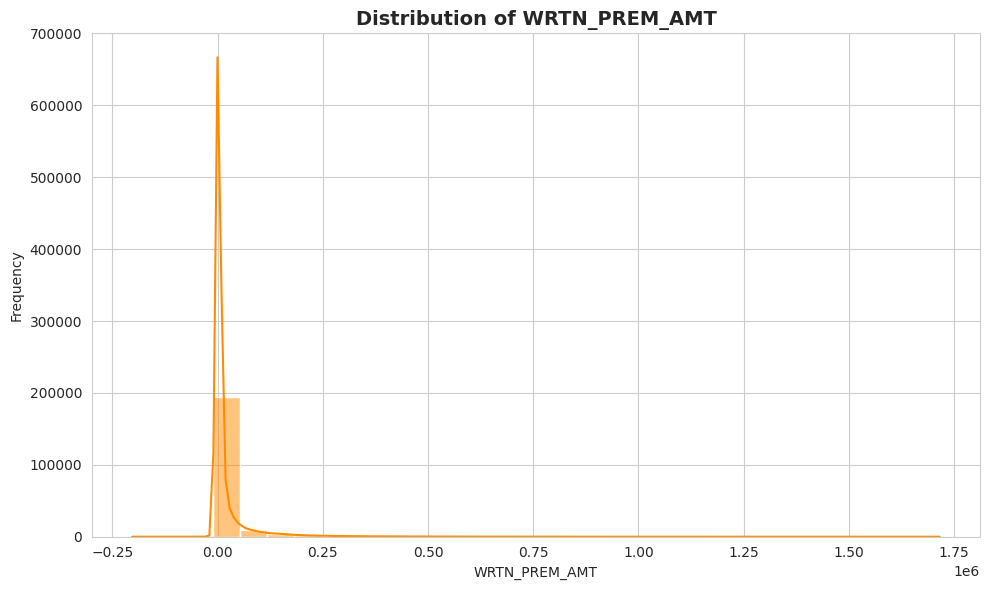

In [13]:
preferred_col = "WRTN_PREM_AMT"
target_col = preferred_col if preferred_col in numeric_cols else (numeric_cols[0] if numeric_cols else None)

if target_col:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[target_col].dropna(), kde=True, color="darkorange", bins=30)
    plt.title(f"Distribution of {target_col}", fontsize=14, fontweight='bold')
    plt.xlabel(target_col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig("chart2_numeric_distribution.png", dpi=150)
    plt.show()
else:
    print("No numeric columns detected to plot.")

Chart 3: Missing value heatmap for a quick visual data quality scan

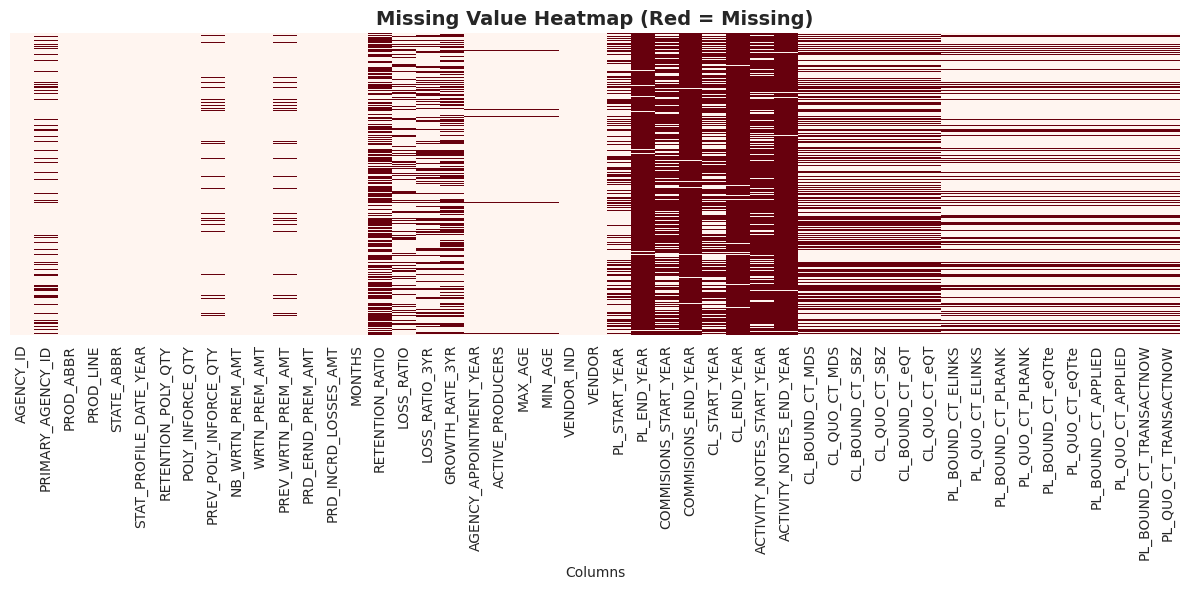

In [14]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isna(), cbar=False, cmap="Reds", yticklabels=False)
plt.title("Missing Value Heatmap (Red = Missing)", fontsize=14, fontweight='bold')
plt.xlabel("Columns")
plt.tight_layout()
plt.savefig("chart3_missing_heatmap.png", dpi=150)
plt.show()

#7. Data Quality Risk Summary

In [15]:
total_rows, total_cols = df.shape
pct_dupes = round(full_dupes / total_rows * 100, 2)
n_high_missing = len(high_missing_cols)
worst_col = data_dictionary.iloc[0]["column_name"] if len(data_dictionary) else "N/A"
worst_pct = data_dictionary.iloc[0]["pct_missing"] if len(data_dictionary) else 0

In [16]:
summary = f'''
DATA QUALITY SUMMARY
=====================
- Dataset size: {total_rows} rows x {total_cols} columns
- Fully duplicated rows: {full_dupes} ({pct_dupes}%)
- Columns exceeding {HIGH_MISSING_THRESHOLD}% missing threshold: {n_high_missing}
- Column with highest missingness: '{worst_col}' ({worst_pct}% missing)
- Categorical columns required cleaning (whitespace/casing inconsistencies): {len(categorical_cols)} columns
- Numeric columns available for analysis: {len(numeric_cols)}

KEY RISKS:
1. SENTINEL VALUES MASKING TRUE MISSINGNESS: {len(sentinel_df)} columns used the placeholder code 99999
   instead of true NULLs (e.g. ratio and "year started" fields). Any analysis run on the raw file BEFORE
   this substitution is corrected would treat 99999 as a real number, badly distorting averages, growth
   rates, and date-based calculations. This is the single most important finding in this profiling pass.
2. Missing data (now correctly surfaced after sentinel replacement) in key fields could bias downstream
   agency performance metrics if not imputed/handled carefully.
3. Inconsistent text casing/whitespace in categorical fields (e.g., product line, state) could fragment
   groupings in aggregation unless cleaned, as done in Section 5.
4. Duplicate rows (if present) could inflate counts/sums in performance metrics.
5. Columns with very high missingness (>{HIGH_MISSING_THRESHOLD}%) may need to be dropped or treated as
   "unknown" categories rather than imputed, since imputation could introduce significant bias.
6. Any identifier columns should be checked for duplicate IDs, since duplicate agency/policy IDs
   could indicate either legitimate multi-record entries (e.g., renewals across years) or data entry errors.
'''
print(summary)


DATA QUALITY SUMMARY
- Dataset size: 213328 rows x 49 columns
- Fully duplicated rows: 0 (0.0%)
- Columns exceeding 30% missing threshold: 16
- Column with highest missingness: 'ACTIVITY_NOTES_END_YEAR' (98.09% missing)
- Categorical columns required cleaning (whitespace/casing inconsistencies): 5 columns
- Numeric columns available for analysis: 44

KEY RISKS:
1. SENTINEL VALUES MASKING TRUE MISSINGNESS: 36 columns used the placeholder code 99999
   instead of true NULLs (e.g. ratio and "year started" fields). Any analysis run on the raw file BEFORE
   this substitution is corrected would treat 99999 as a real number, badly distorting averages, growth
   rates, and date-based calculations. This is the single most important finding in this profiling pass.
2. Missing data (now correctly surfaced after sentinel replacement) in key fields could bias downstream
   agency performance metrics if not imputed/handled carefully.
3. Inconsistent text casing/whitespace in categorical fields (e.g

In [17]:
# Conclusions
# - The dataset's overall structure and types were validated rather than assumed, per the assignment requirements.
# - A reusable data dictionary function was built so the profiling step can be re-run on similar datasets.
# - The 99999 sentinel value was explicitly detected and converted to NaN before any missing-value
#   or distribution analysis — this was the most consequential cleaning step.
# - Missing-value and duplicate-record checks revealed the dataset's main quality risks (see Section 7).
# - Categorical fields were standardized (trimmed, title-cased) to prevent silent fragmentation of groups
#   in later analysis.
# - Next steps for any analyst using this dataset downstream: decide on an imputation/drop strategy for
#   high-missing columns, confirm whether AGENCY_ID/PRIMARY_AGENCY_ID combinations should be unique per
#   year/product/state, and re-validate column semantics (ratio vs. amount vs. count) before building
#   agency performance metrics.